In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any
import albumentations as A
import PIL

from project_root import PROJECT_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout

import torchvision

In [2]:
coco_root = Path("/home/dherrera/data/coco")
data_root = Path("/home/dherrera/data/elephants")

In [3]:
from scripts.model_serialization import load_model

model_dir = PROJECT_ROOT / "models/segmentation/mask2former/v3/config.ptc"
model_trained = load_model(model_dir)

from transformers import Mask2FormerImageProcessor

image_processor = Mask2FormerImageProcessor.from_pretrained(model_dir.parent)

model_trained.eval()
model_trained

2025-04-23 14:27:51.537484: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 14:27:51.543929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745411271.551608   56949 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745411271.553971   56949 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745411271.559916   56949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

RecursiveScriptModule(
  original_name=Mask2FormerAdapter
  (mask2former): RecursiveScriptModule(
    original_name=Mask2FormerForUniversalSegmentation
    (model): RecursiveScriptModule(
      original_name=Mask2FormerModel
      (pixel_level_module): RecursiveScriptModule(
        original_name=Mask2FormerPixelLevelModule
        (encoder): RecursiveScriptModule(
          original_name=SwinBackbone
          (embeddings): RecursiveScriptModule(
            original_name=SwinEmbeddings
            (patch_embeddings): RecursiveScriptModule(
              original_name=SwinPatchEmbeddings
              (projection): RecursiveScriptModule(original_name=Conv2d)
            )
            (norm): RecursiveScriptModule(original_name=LayerNorm)
            (dropout): RecursiveScriptModule(original_name=Dropout)
          )
          (encoder): RecursiveScriptModule(
            original_name=SwinEncoder
            (layers): RecursiveScriptModule(
              original_name=ModuleList
     

In [4]:
# with (PROJECT_ROOT / "data/config.json").open() as f:
#     config = json.load(f)
# classes = [(data["id"], name) for name, data in config["individuals"].items()]
# classes = sorted(classes, key=lambda x: x[0])
# classes = [f"{x[0]:02}_{x[1]}" for x in classes]
# print(classes)
print(fo.list_datasets())

['coco-elephants-train2017', 'coco-elephants-val2017', 'zoo-elephants-detection', 'zoo-elephants-detection-train', 'zoo-elephants-detection-val', 'zoo-elephants-identity', 'zoo-elephants-identity-certainty-good', 'zoo-elephants-identity-certainty-val', 'zoo-elephants-identity-d2', 'zoo-elephants-identity-id3', 'zoo-elephants-identity-tracks', 'zoo-elephants-identity-train', 'zoo-elephants-identity-v1-curated', 'zoo-elephants-identity-v1-val', 'zoo-elephants-identity-v4', 'zoo-elephants-identity-val', 'zoo-elephants-sleep', 'zoo-elephants-sleep-mix', 'zoo-elephants-sleep-train', 'zoo-elephants-sleep-v1', 'zoo-elephants-sleep-v2', 'zoo-elephants-sleep-val', 'zoo-elephants-sleep-val2']


In [5]:
# from PIL import Image
# for sample in ds_zoo_elephants.iter_samples():
#   im = np.asarray(Image.open(sample.filepath).convert("RGB"))
#   result = fo_model.predict(im)
#   print(result)
#   sample.add_labels(result, label_field="zoo_identity")
#   break

Stats for zoo-elephants-detection: {'samples_count': 12437, 'samples_bytes': 7940696, 'samples_size': '7.6MB', 'media_bytes': 0, 'media_size': '0.0B', 'total_bytes': 7940696, 'total_size': '7.6MB'}
<Sample: {
    'id': '6808d791aa9a54d22d8cfc48',
    'media_type': 'image',
    'filepath': '/home/dherrera/data/elephants/segmentation/coco/train2017/000000384553.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': None,
        'mime_type': None,
        'width': 640,
        'height': 425,
        'num_channels': None,
    }>,
    'created_at': datetime.datetime(2025, 4, 23, 12, 5, 37, 672000),
    'last_modified_at': datetime.datetime(2025, 4, 23, 12, 27, 10, 134000),
    'segmentation_pred': <Detections: {
        'detections': [
            <Detection: {
                'id': '6808dc9e5334336ab492141b',
                'attributes': {},
                'tags': [],
                'label': 'elephant',
                'bounding_box': [
                    0.9471

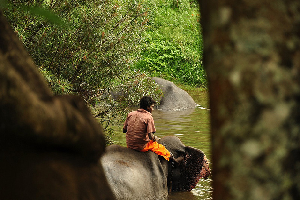

In [6]:
ds_name = "zoo-elephants-detection"
ds_zoo_elephants = fo.load_dataset(ds_name)
print(f"Stats for {ds_name}: {ds_zoo_elephants.stats(include_media=True)}")

sample0 = next(ds_zoo_elephants.iter_samples())
im0 = PIL.Image.open(sample0["filepath"])
print(sample0)
im0.resize((300, 200), 0)

In [7]:
image_height = 600
image_width = 1060
resize_transforms = A.Compose(
    [
        A.LongestMaxSize(max_size_hw=(image_height, image_width)),
        A.PadIfNeeded(min_height=image_height, min_width=image_width),
    ]
)


def transform_and_preprocess(image: PIL.Image):
    image = np.asarray(image)
    image = resize_transforms(image=image)["image"]
    image = image_processor.preprocess(image)["pixel_values"][0]
    image = torch.from_numpy(image)
    # raise RuntimeError(f"type is {type(image)}, {str(image.shape)=}")
    return image


transforms = transform_and_preprocess
im0t = transforms(im0).unsqueeze(0).to(torch.device("cuda"))
print(f"{im0t.shape=}")

im0t.shape=torch.Size([1, 3, 600, 1060])


In [8]:
im0res = model_trained(im0t)
im0res["boxes"]

tensor([[251,  77, 265, 150],
        [ 97,  58, 177, 150],
        [  0,   0, 145, 150],
        [136,  58, 166,  82],
        [  0,   0, 107, 150],
        [  0,   1, 106, 150],
        [  0,   0, 265, 150],
        [  0,   0, 265, 150],
        [  0,   1, 100, 150],
        [  0, 138, 108, 150],
        [ 97,  58, 167,  83],
        [ 96, 103, 177, 150],
        [  0,   0, 265, 150],
        [  0,  68, 177, 150],
        [  0,   0, 167, 150],
        [237,  19, 265, 150],
        [  0,   6, 177, 150],
        [  0,  46, 176, 150],
        [257,  80, 265, 149],
        [  0,   1,  26, 137],
        [  0,   0, 167, 150],
        [  0, 112,  43, 150],
        [  0,   0, 265, 150],
        [  0, 110,  99, 150],
        [ 97,  58, 167,  83],
        [  0,   1, 177, 150],
        [  0,   0, 176, 150],
        [  0,   1, 176, 150],
        [  0,   0, 167, 150],
        [  0, 105, 107, 150],
        [  0,   0,  59,  87],
        [  0,   0,  58,  81],
        [251,  76, 265, 150],
        [ 

In [9]:
print(im0res["masks"].shape)
im0res["boxes"]

torch.Size([100, 150, 265])


tensor([[251,  77, 265, 150],
        [ 97,  58, 177, 150],
        [  0,   0, 145, 150],
        [136,  58, 166,  82],
        [  0,   0, 107, 150],
        [  0,   1, 106, 150],
        [  0,   0, 265, 150],
        [  0,   0, 265, 150],
        [  0,   1, 100, 150],
        [  0, 138, 108, 150],
        [ 97,  58, 167,  83],
        [ 96, 103, 177, 150],
        [  0,   0, 265, 150],
        [  0,  68, 177, 150],
        [  0,   0, 167, 150],
        [237,  19, 265, 150],
        [  0,   6, 177, 150],
        [  0,  46, 176, 150],
        [257,  80, 265, 149],
        [  0,   1,  26, 137],
        [  0,   0, 167, 150],
        [  0, 112,  43, 150],
        [  0,   0, 265, 150],
        [  0, 110,  99, 150],
        [ 97,  58, 167,  83],
        [  0,   1, 177, 150],
        [  0,   0, 176, 150],
        [  0,   1, 176, 150],
        [  0,   0, 167, 150],
        [  0, 105, 107, 150],
        [  0,   0,  59,  87],
        [  0,   0,  58,  81],
        [251,  76, 265, 150],
        [ 

In [10]:
import gc

gc.collect()
from accelerate.utils import release_memory

release_memory()

[]

In [11]:
import fiftyone.core.labels as fol
import itertools


class Mask2FormerOutputProcessor(fo.utils.torch.OutputProcessor):
    def __init__(self, classes=None, mask_thresh=0.5):
        if classes is None:
            raise ValueError(
                "This model requires class labels, but none were available"
            )

        self.classes = classes
        self.mask_thresh = mask_thresh

    def __call__(self, output, frame_size, confidence_thresh=None):
        if isinstance(output, list):
            return [
                self._parse_output(o, frame_size, confidence_thresh) for o in output
            ]
        else:
            return [self._parse_output(output, frame_size, confidence_thresh)]

    def _parse_output(self, output, frame_size, confidence_thresh):
        width, height = frame_size

        # test_im = np.zeros((height,width),dtype=np.uint8)
        # test_imt = resize_transforms(image=test_im)["image"]
        # width_resized,height_resized = test_imt.shape[-1],test_imt.shape[-2]
        # pad_x = (widt)

        boxes = output["boxes"].detach().cpu().numpy()
        labels = output["labels"].detach().cpu().numpy()
        masks = output["masks"].detach().cpu().numpy()
        if "scores" in output:
            scores = output["scores"].detach().cpu().numpy()
        else:
            scores = itertools.repeat(None)

        mask_width, mask_height = masks.shape[-1], masks.shape[-2]

        detections = []
        for box, label, mask, score in zip(boxes, labels, masks, scores):
            if (
                confidence_thresh is not None
                and score is not None
                and score < confidence_thresh
            ):
                continue

            x1, y1, x2, y2 = box
            mask = mask[
                int(round(y1)) : int(round(y2)),
                int(round(x1)) : int(round(x2)),
            ]

            if mask.dtype != bool:
                mask = mask > self.mask_thresh

            x1 *= 1 / mask_width
            x2 *= 1 / mask_width
            y1 *= 1 / mask_height
            y2 *= 1 / mask_height
            bounding_box = [
                x1,
                y1,
                (x2 - x1),
                (y2 - y1),
            ]

            detections.append(
                fol.Detection(
                    label=self.classes[label],
                    bounding_box=bounding_box,
                    mask=mask,
                    confidence=score,
                )
            )

        return fol.Detections(detections=detections)


classes = ["elephant"]
output_processor = Mask2FormerOutputProcessor(classes)
output_processor(model_trained(im0t), frame_size=(10, 60))

[<Detections: {
     'detections': [
         <Detection: {
             'id': '6808dccc33f623e866e70225',
             'attributes': {},
             'tags': [],
             'label': 'elephant',
             'bounding_box': [
                 0.9471698113207547,
                 0.5133333333333334,
                 0.05283018867924527,
                 0.4866666666666666,
             ],
             'mask': array([[False, False, False, ...,  True, False, False],
                    [False, False, False, ...,  True, False, False],
                    [False, False, False, ...,  True, False, False],
                    ...,
                    [False,  True,  True, ...,  True,  True,  True],
                    [False,  True,  True, ...,  True,  True,  True],
                    [False, False, False, ...,  True,  True,  True]]),
             'mask_path': None,
             'confidence': 0.010439474135637283,
             'index': None,
         }>,
         <Detection: {
             

In [12]:
session = fo.launch_app(ds_zoo_elephants, auto=False)


# weights = torchvision.models.get_weight("MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1")
# transforms = weights.transforms()


config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model_trained,
        "entrypoint_args": {},
        "output_processor": output_processor,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

predictions_view = ds_zoo_elephants.take(100)
# print(sample)
predictions_view.apply_model(fo_model, label_field="segmentation_pred")
# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)

session.view = predictions_view
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.
 100% |█████████████████| 100/100 [11.2s elapsed, 0s remaining, 11.0 samples/s]      


<IPython.core.display.Javascript object>